# Load Dataset

In [11]:
import pandas as pd

imdb_top = pd.read_csv("imdb_top_1000.csv")
df = pd.DataFrame(data = imdb_top.values, columns = imdb_top.columns)
print(imdb_top.columns)

df = imdb_top.copy()

df['Encoded_Rating'] = pd.factorize(df['IMDB_Rating'])[0]

print("DataFrame Head: ")
print(df.head())
print("\nDataFrame Info: ")
print(df.info())


Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='str')
DataFrame Head: 
                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

            

In [15]:
from IPython.display import HTML, display

#  Movie1 jpg
movie1_url = "https://m.media-amazon.com/images/M/MV5BMzUzNDM2NzM2MV5BMl5BanBnXkFtZTgwNTM3NTg4OTE@._V1_UX67_CR0,0,67,98_AL_.jpg"
# Movie2 jpg
movie2_url = "https://m.media-amazon.com/images/M/MV5BNmY0MWY2NDctZDdmMi00MjA1LTk0ZTQtZDMyZTQ1NTNlYzVjXkEyXkFqcGdeQXVyMjUzOTY1NTc@._V1_UX67_CR0,0,67,98_AL_.jpg"

# Display the images side by side
display(HTML(f"""
<div style="display: flex; justify-content: space-around;">
    <img src="{movie1_url}" width="300" height="450">
    <img src="{movie2_url}" width="300" height="450">
</div>
"""))


# Exploratory Data Analysis(EDA)

In [16]:
print("\nDescriptive Statistics: ")
print(df.describe())


Descriptive Statistics: 
       IMDB_Rating  Meta_score   No_of_Votes  Encoded_Rating
count  1000.000000  843.000000  1.000000e+03     1000.000000
mean      7.949300   77.971530  2.736929e+05       12.509000
std       0.275491   12.376099  3.273727e+05        2.745807
min       7.600000   28.000000  2.508800e+04        0.000000
25%       7.700000   70.000000  5.552625e+04       11.000000
50%       7.900000   79.000000  1.385485e+05       13.000000
75%       8.100000   87.000000  3.741612e+05       15.000000
max       9.300000  100.000000  2.343110e+06       16.000000


Generating pair plot...


<Figure size 1000x800 with 0 Axes>

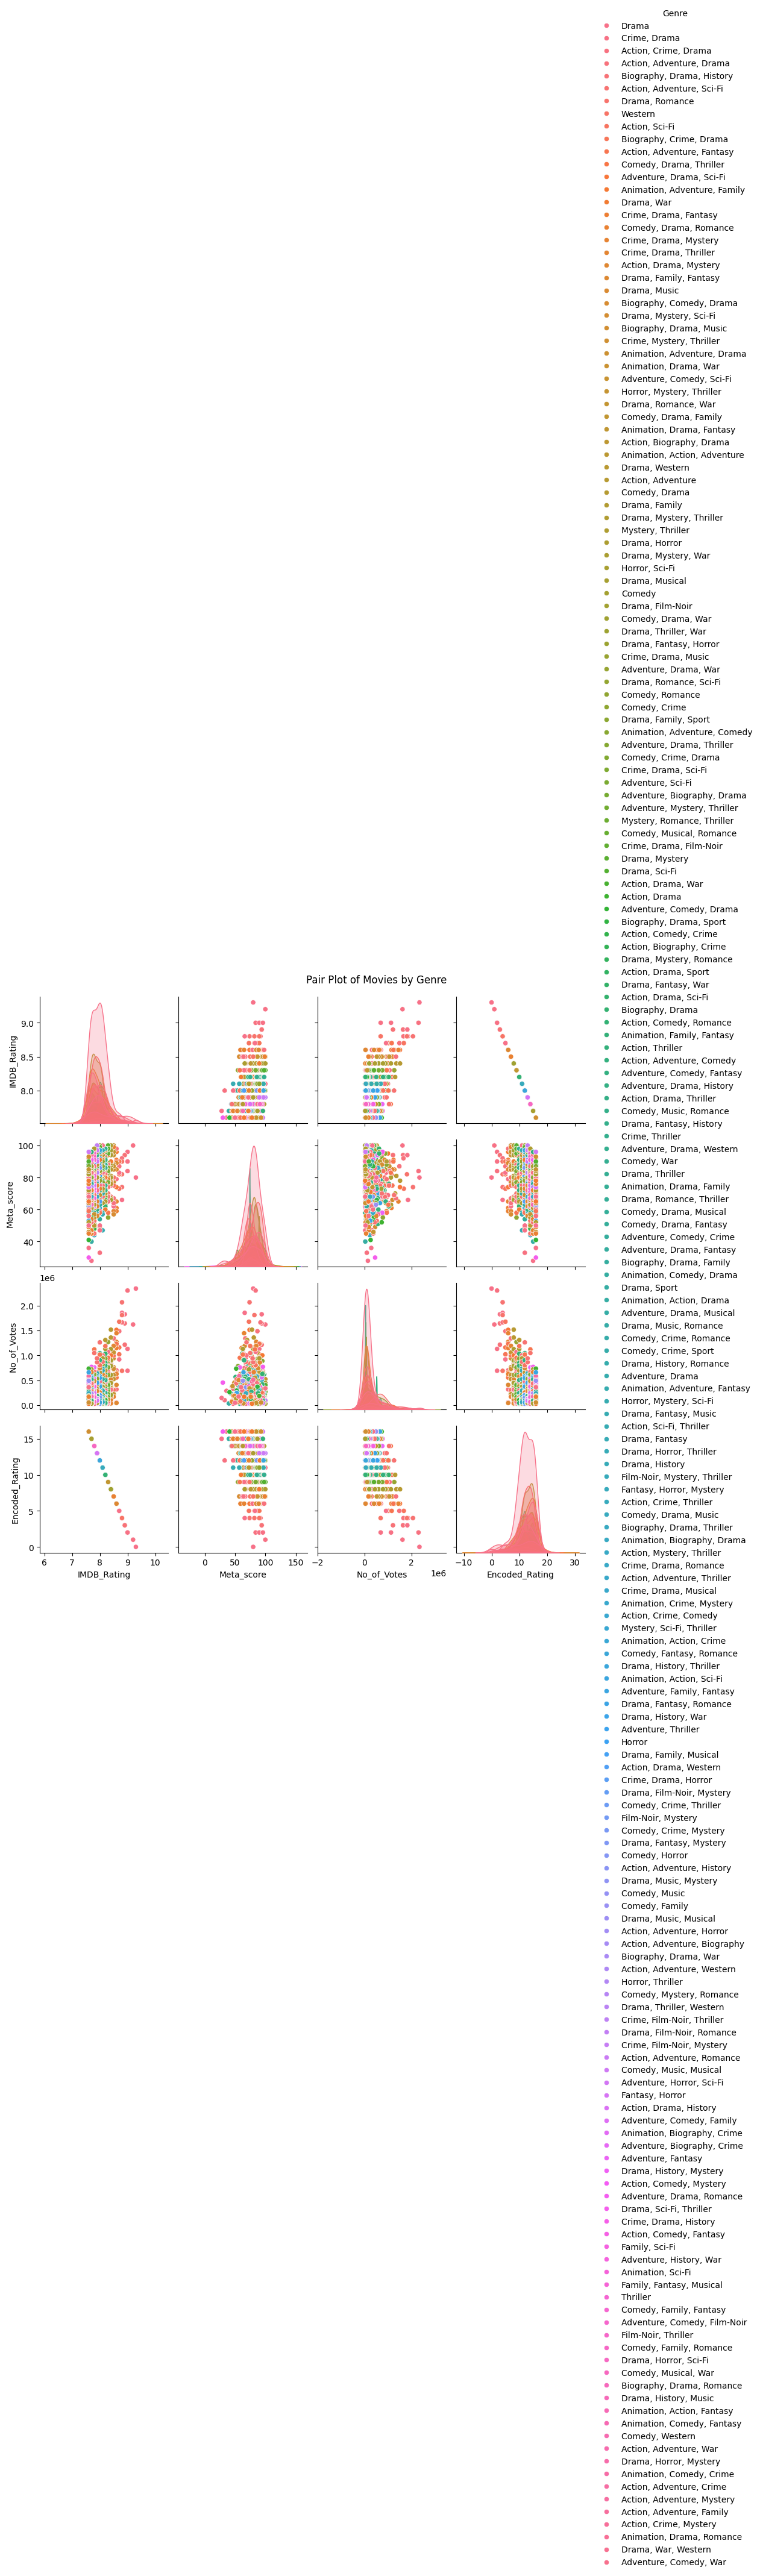

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating pair plot...")
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='Genre', diag_kind='kde')
plt.suptitle('Pair Plot of Movies by Genre', y=1.02)
plt.show()

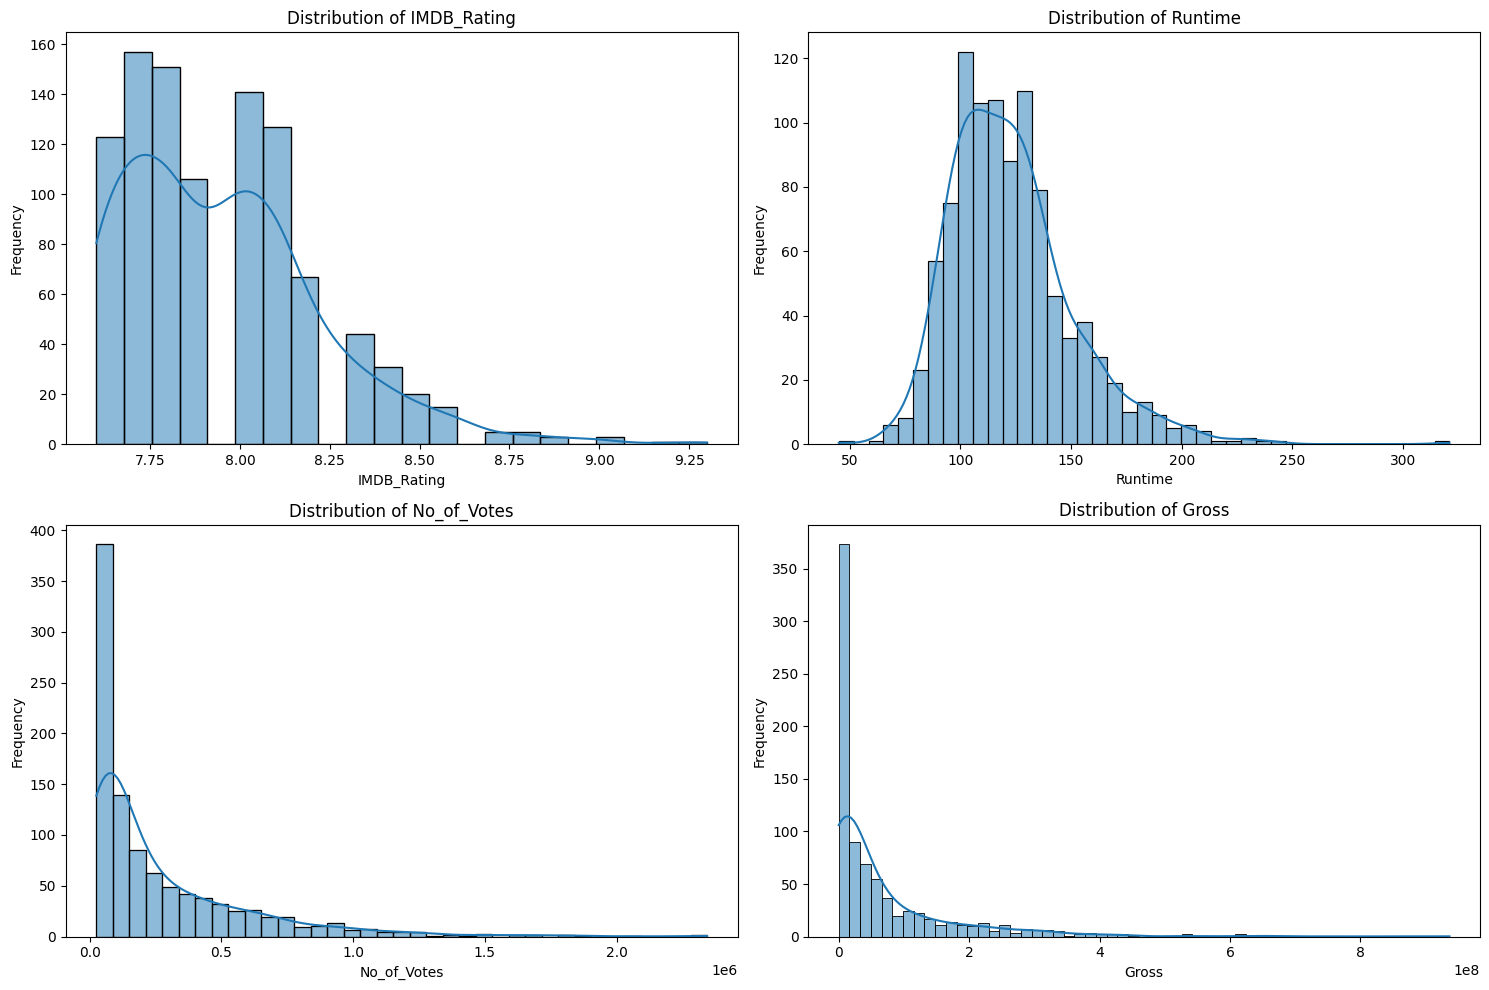

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


numerical_cols = ['IMDB_Rating', 'Runtime', 'No_of_Votes', 'Gross']

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

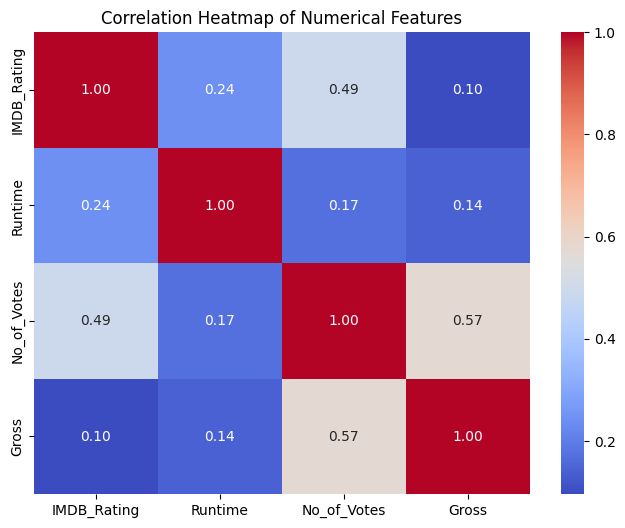

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
plt.figure(figsize=(5, 5))

# Get unique species and their encoded values to create custom labels
species_map = df[['Genre', 'Encoded_Rating']].drop_duplicates().set_index('Genre').squeeze().to_dict()
labels = [f"{s} ({species_map[s]})" for s in df['Genre'].unique()]

colors = sns.color_palette('colorblind')

plt.pie(df['Genre'].value_counts(), labels=labels, autopct='%1.1f%%', startangle=150, colors=colors)
plt.title('Distribution of Genres')
plt.show()

## Data Preparation

Prepare the data for machine learning. This involves shuffling the dataset, splitting it into training and testing sets, and applying label encoding to the target variable if it's in string format, converting it to numerical labels.
